In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

sys.path.append(os.path.abspath("../../espaloma-charge_mod/"))
sys.path.append(os.path.abspath('../')) 
import ResParTools as pt
from espaloma_charge import charge
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import json
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
# import psiresp
import nglview as nv
import MDAnalysis as mda
import glob
import re

import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

In [2]:
# Лог для отладки: вызовы функций pt, их параметры, сообщения, словари сопоставления
# и промежуточные молекулы пишутся в logs/<дата_время>/ (log.txt, calls.jsonl, files/).
# Выключить: pt.stop_log()
log_dir = pt.start_log()

Лог включён: /home/nikolay/Documents/VS_code/ResParTools/notebooks_and_examples/AF_546_cys/logs/2026-09-28_15-37-06


In [3]:
!pwd

/home/nikolay/Documents/VS_code/ResParTools/notebooks_and_examples/AF_546_cys


# Протокол расчета парциальных зарядов для модифицированных аминокислот
На вход подаються .smi-файлы мономера и полимеров аминокислоты, где аминокислота входит в состав полимера в положениях N M C. 
У мономера должны бать группы COO<sup>-</sup> и N<sup>+</sup>H<sub>3</sub>. У полимеров соответствующие группы на С и N концах.  

In [5]:
PTM_name = 'C_AF546'
base_name = 'C546'

## Шаг 1 Открытие .smi-файлов 
Мы рекомендуем использовать словари для записи фаилов молекул, также можно передать путь к  `.smi` в виде строки или листа. На выход вы получите словарь с соответствующими ключами. 

In [7]:
monomer_smi = pt.read_file(f'molecules/C_AF_546.smiles')
# monomer_smi =mon_name.read_file('molecules/R_CIT.smiles')
trimers_smi = pt.read_file([
                            f'molecules/ACA_AF_546.smiles', 
                            # 'molecules/GRG_CIT.smiles',
                            # 'molecules/GR_CIT.smiles',

                           ],)
monomer_chem = pt.smi_to_chem(monomer_smi) # RDKit читает smi строку, переводит в chem и добавляет протоны
trimers_chem = pt.smi_to_chem(trimers_smi)
trimers_chem

{'ACA_AF_546': <rdkit.Chem.rdchem.Mol at 0x7ff641b04820>}

In [8]:
# os.path.basename('molecules/AKA_1M.smiles').split('.')[0]
mon_name = str(*monomer_smi.keys())
pol_name = str(*trimers_smi.keys())
print(mon_name, pol_name, sep='\n')

C_AF_546
ACA_AF_546


## Шаг 2 Поиск подструктур мономера а.к. в полмерах
Наша задача выделить те атомы в составе полимеров, которые входят в состав мономера. Для этого функция `match_mon_to_pol` принимает на вход пару словарей с `Chem` фаилами. Словарь мономеров (один мономер) и полимеров (от 1 до ∞) соответственно. На выход подается словарь с ключами: `substructure`, `mon_pol_matches`, `N_match_atoms`, для кажого из полимеров. \
Где:
- `substructure` - сожердит общие подструктуры мономера и полимера, для каждого из полимеров в формате Chem .
- `mon_pol_matches` - содержит словари соответствия номеров атомов в общей подструктуре с номерами атомов в полимере молекула из общей подструктуры.
- `N_match_atoms` - количество общих атомов для мономера и полимера.\ 
(обычно вам не понадобится этот ключ, но он используется для подсвечивания общей структуры полимера на мономере)

Обратите внимание что набор атомов подструктур внутри мономера различается в зависимости от расположения а.к. в полимере

In [10]:
match_dict = pt.match_mon_to_pol(monomer_chem, trimers_chem, only_heavy_mapping = True,
                                timeout = 3)
# match_dict
print(match_dict.keys(),match_dict['substructure'], sep='\n')

Выполнение Поиск подструктуры между молекулами.  

Выполнение Поиск подструктуры между молекулами.. 

Выполнение Поиск подструктуры между молекулами...

Выполнение Поиск подструктуры между молекулами.  

Выполнение Поиск подструктуры между молекулами.. 

Выполнение Поиск подструктуры между молекулами...


Поиск подструктуры между молекулами выполнен успешно!
⚠ MCS остановлен по timeout, подструктура может быть неполной
dict_keys(['substructure', 'substructure_noH', 'mon_pol_matches', 'N_match_atoms', 'mon_pol_atom_names'])
{'C_AF_546': <rdkit.Chem.rdchem.Mol object at 0x7ff641b04ba0>}


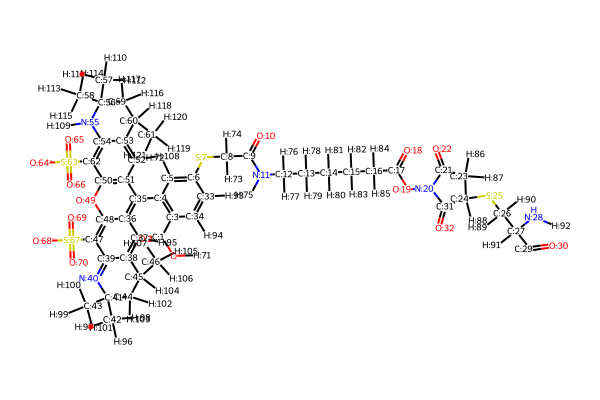

In [11]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

### Отрисовка полученных подструктур на молекулах мономера и полимера
Позволяет убедится в корректности структур

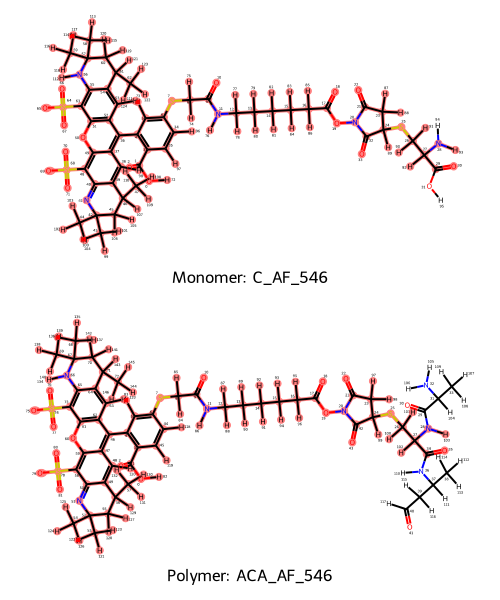

In [13]:
pt.draw_mon_pol_match(monomer_chem, trimers_chem, match_dict, add_small_atom_index=True, prefer_coord_gfen= False)

## Шаг 3 Сохранение молекул подструктур для N M С позиций 

Из молекулы мономера были выделены структуры аминокислот для каждой из позиций `N` `M` `C`. Важно ответить, что при созранение подструктур идет переупордочивание атомов таким образом, что первым атомом в молекуле становится автом **N** в составе аминогруппы. Далее имено они будут использоваться при получении файлов топологии. \
Ниже представленно несколько вариантов сохранения подструктур, но в итоге будут использоватсья файлы формата `.pdb` 

Были получены молекулярные формулы параметризируемых остатков `match_dict['substructure']`. Именно они будут использоваться для получения фаилов топологии в следующем ноутбуке.

#### Сохранение подструктур в виде **smiles**

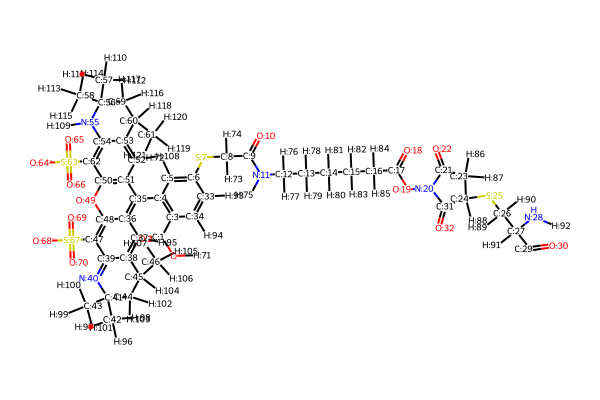

In [14]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

In [15]:
for chem_name, chem_mol in  match_dict['substructure'].items():
    print(chem_name, chem_mol)
    pt.save_aa_chem_to_smiles(chem_mol, f'molecules/substructure/{chem_name}', canonical=False ,make_N_root=False)

C_AF_546 <rdkit.Chem.rdchem.Mol object at 0x7ff641b04ba0>
C_AF_546.smiles saved to molecules/substructure


##### Проверка сохраненных подструктур

In [16]:
test_smi = pt.read_file([f'molecules/substructure/{mon_name}.smiles',
                        ])
test_chem = pt.smi_to_chem(test_smi, addH=False, sanitize=False)
IPythonConsole.drawOptions.addAtomIndices = False

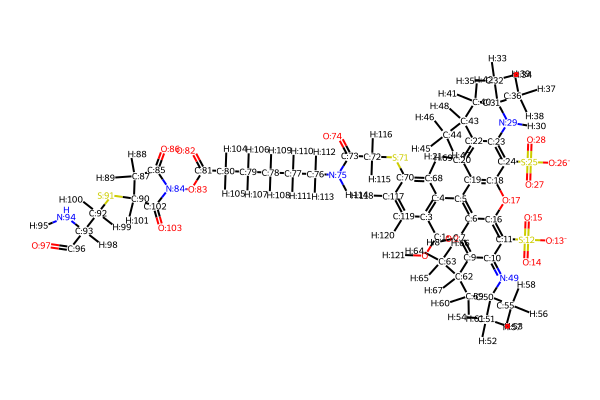

In [17]:
pt.draw_mol_with_atom_index(test_chem[mon_name])

### Сохранение подструктур в виде mol

In [30]:
list_N = []
for sub in match_dict['substructure'].values():
    N_index = pt.find_amino_nitrogen(sub)
    list_N.append(N_index)
print(list_N)
sub_name = ['NR_CIT', 'R_CIT', 'CR_CIT']
for chem_name, chem_mol, root in zip(sub_name, match_dict['substructure'].values(), list_N):
    pt.save_chem_to_mol(chem_mol, f'molecules/substructure/{chem_name}', rootedAtAtom = root)
    print(chem_name, chem_mol)

10
10
11
[10, 10, 11]
NR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bee0>
R_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bf40>
CR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f9480340400>


In [53]:
mol_test = Chem.MolFromMolFile('molecules/substructure/NR_CIT.mol', sanitize=False,removeHs=False)
# Chem.AddHs(mol_test)

### Сохранение подструктур в виде **pdb**

То как выглядит подструктура для одного из вариантов позиционирования остатка в цепи:

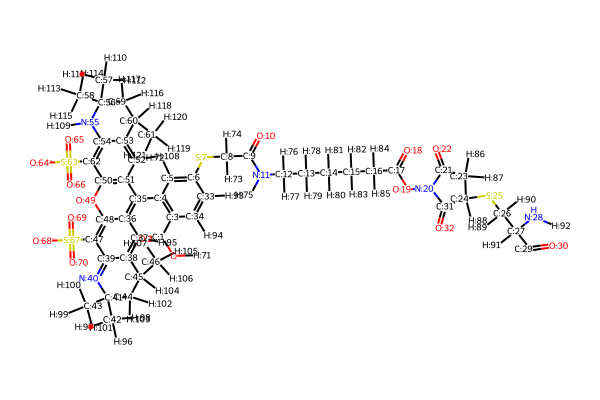

In [18]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

Сохранение подструктуры (т.е. атомов входящих в состав модифицированного остатка в зависимости от его позиции в полимере) в формате 
`pdb`. \
Далее полученные ДНК используются для получения парциальных зарядов и для получения файлов топологии. \
Кроме этого вы можете взять их и использовать в молекулярном  моделировании для добавления модифицированного остатка в вашу структуру.   

##### Одиночное сохранение:
Мы сохраняем остаток ак в составе которго атомы только входящие в этот остаток. \
Все имен аатомов уникальные

In [19]:
pt.save_aa_chem_to_pdb(match_dict[f'substructure'][mon_name], 
                       f'molecules/substructure/{mon_name}', 
                       resname = base_name, # только три буквы !
                       resid= 2,
                       segid= 'A',
                       make_N_root=False)

[15:37:10] Molecule does not have explicit Hs. Consider calling AddHs()


[15:37:11] Molecule does not have explicit Hs. Consider calling AddHs()


⚠ Имя остатка 'C546' длиннее 3 символов: RDKit запишет в PDB только 'C54'.

Уровень 1: 1 атомов
  Буква уровня: B
    CB (бывший) -> CB1 (индекс 1)
      водород HB11
      водород HB12

Уровень 2: 1 атомов
  Буква уровня: G
    SG (бывший) -> SG1 (индекс 1)

Уровень 3: 1 атомов
  Буква уровня: D
    CD (бывший) -> CD1 (индекс 1)
      водород HD1

Уровень 4: 2 атомов
  Буква уровня: E
    CE (бывший) -> CE1 (индекс 1)
      водород HE11
      водород HE12
    CE (бывший) -> CE2 (индекс 2)

Уровень 5: 3 атомов
  Буква уровня: Z
    CZ (бывший) -> CZ1 (индекс 1)
    OZ (бывший) -> OZ2 (индекс 2)
    NZ (бывший) -> NZ3 (индекс 3)

Уровень 6: 2 атомов
  Буква уровня: H
    OH (бывший) -> OH1 (индекс 1)
    OH (бывший) -> OH2 (индекс 2)

Уровень 7: 1 атомов
  Буква уровня: T
    CT (бывший) -> CT1 (индекс 1)

Уровень 8: 2 атомов
  Буква уровня: I
    CI (бывший) -> CI1 (индекс 1)
      водород HI11
      водород HI12
    OI (бывший) -> OI2 (индекс 2)

Уровень 9: 1 атомов
  Буква уровня: K


##### Множественное сохранение:

In [10]:
sub_name = ['NR_CIT_1', 'R_CIT_1', 'CR_CIT_1']
resname_l = ['NRC', 'RC', 'CRC']
for chem_name, chem_mol, resname in zip(sub_name, match_dict['substructure'].values(), resname_l):
    pt.save_aa_chem_to_pdb(chem_mol, f'molecules/substructure/{chem_name}_rdkit', resname = resname, make_N_root=True)

atom number: 0 became the root atom: 0
Длина atom_names_list не совпадает с количеством атомов в rdkit_mol. Будут использованы стандартные имена атомов.
NR_CIT_1_rdkit.pdb saved to moleculse/substructure


[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()
[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()


#### Проверка сохраненных молекул

In [20]:
if '_H' in mon_name:
    mon_name_no_H = mon_name.replace('_H','_no_H')
else:
    mon_name_no_H = mon_name + '_no_H'

In [21]:
# test_pdb = pt.pdb_to_chem(f'Lysine_Cro/molecules/substructure/Kcr_H2.pdb',
test_pdb = pt.pdb_to_chem([
            f'molecules/substructure/{mon_name}.pdb',
            f'molecules/substructure/{mon_name_no_H}.pdb'
              # 'molecules/substructure/CR_CIT.pdb'
                          ])
test_pdb

{'C_AF_546': <rdkit.Chem.rdchem.Mol at 0x7ff7a51c1e70>,
 'C_AF_546_no_H': <rdkit.Chem.rdchem.Mol at 0x7ff7a51c2a40>}

Если все получилось, то вы молжны получить картинку тогоже остатка с такимиже типами связей и количеством атомов. \
В случае если вы использовали `make_N_root=True` последовательность нумерации атомов должна была поменяться и нулевым атомом должен был стать `N` в аминогруппе

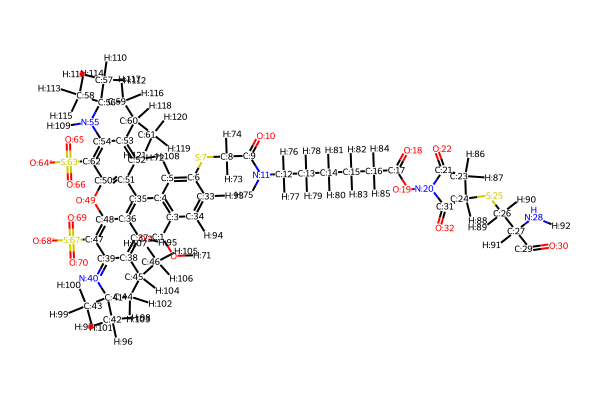

In [22]:
pt.draw_mol_with_atom_index(test_pdb[mon_name])

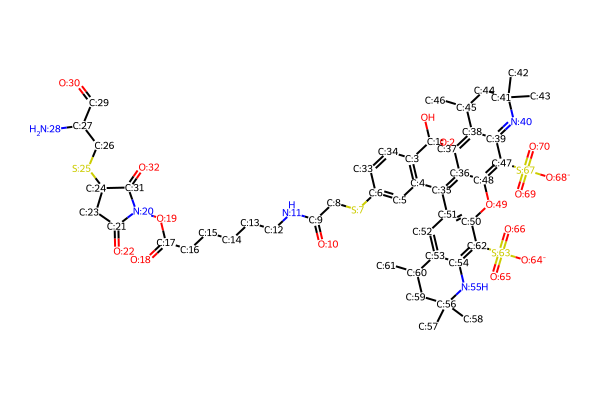

In [23]:
pt.draw_mol_with_atom_index(test_pdb[mon_name_no_H])

##### NGLview отрисовка

Поскольку мы сохранили pdb фаил то можно и через MDAnalysis и nglview посмотреть на него

In [23]:
nv.show_mdanalysis(mda.Universe(f'{PTM_name}/molecules/substructure/{mon_name}.pdb'))

FileNotFoundError: [Errno 2] No such file or directory: 'C_AF546/molecules/substructure/C_AF_546.pdb'

## Шаг 4 Переименовка атомов в составе остатка с присвоением канонических имен к каноничным атомам  

Полученные на шаге 3 были полученые структуры остатков. Данные структуры имеют как канонические атомы (т.е. входят в состав каноничных аминокислоты), так и не канонические -- новые. \
На шаге 4 мы находим соствае парметризуемого остатка канонические атомы, которыек сохранилди ориганльные валентности и присваиваем им канонические имена атомов.

In [23]:
# PTM_name = 'Lysine_Cro'
# mon_name = 'Kcr_H'

print(mon_name, pol_name, sep='\n')

Lysine_1M
AKA_1M


### Сопоставление модифицированного остатка с референсными остатками

In [24]:
path_to_mod_aa = f'molecules/substructure/{mon_name}.pdb'

mod_aa_name = os.path.basename(path_to_mod_aa).split('.')[0]
print(mod_aa_name)
mod_aa_chem_dict = pt.pdb_to_chem(path_to_mod_aa)

ref_aa_chem_dict, match_data_dict, name_ref_triplet = pt.find_ref_aa(mod_aa_chem_dict, match_residue_number = 2, 
                                                                     main_match_data=True)   

Lysine_1M
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Reference amino acid is Lys, with 21 matched atoms.


In [25]:
# match_data_dict

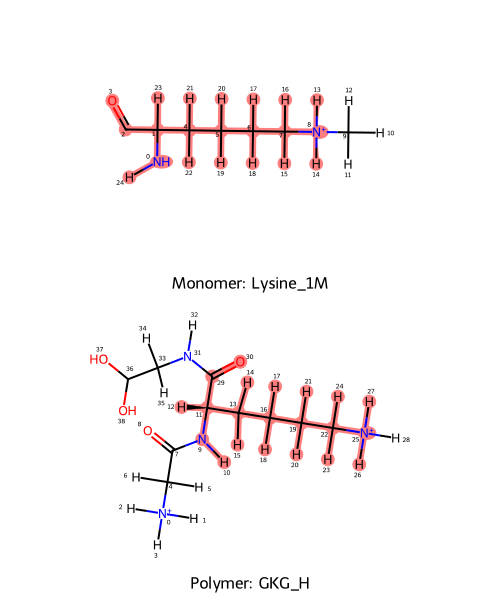

In [26]:
pt.draw_mon_pol_match(mod_aa_chem_dict, ref_aa_chem_dict, match_data_dict, 
                      add_small_atom_index=True, prefer_coord_gfen = False)

In [27]:
pt.save_json('general_atoms', list(*match_data_dict['mon_pol_atom_names'].values()), )

Файл успешно сохранен: 
/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_1M/general_atoms.json


### Переименовка атомов в модифицированном остатке

In [28]:
from collections import Counter

from rdkit import Chem
from rdkit.Chem import AllChem

def check_PDB_residue_info(atom):
    """
    Проверяет, что параметры остатка были правильно установлены для атома.
    """
    monomer_info = atom.GetMonomerInfo()
    # assert monomer_info.IsValid(), "Информация об остатке не установлена!"
    assert monomer_info.GetName().strip(), "Имя атома не установлено!"
    assert monomer_info.GetResidueName().strip(), "Имя остатка не установлено!"
    assert monomer_info.GetResidueNumber() >= 1, "Номер остатка не установлен!"
    assert monomer_info.GetChainId().strip(), "ID сегмента не установлен!"
    print(f"Параметры остатка для атома {monomer_info.GetName()} установлены корректно.", 
          monomer_info.GetName(), 
          monomer_info.GetResidueName(),
        monomer_info.GetResidueNumber(),
        monomer_info.GetChainId(),sep='\n')

def check_duplicate_atom_names(mol):
    """
    Проверяет наличие атомов с одинаковыми именами в молекуле и возвращает словарь.
    """
    # Получаем список всех имен атомов
    atom_names = [atom.GetProp('AtomName') for atom in mol.GetAtoms()]

    # Подсчитываем частоту появления каждого имени
    name_count = Counter(atom_names)
    print(name_count)
    # Формируем словарь с именами атомов и их индексами в молекуле
    atom_indices = {}
    for i, atom in enumerate(mol.GetAtoms()):
        name = atom.GetProp('AtomName')
        if name in atom_indices:
            atom_indices[name].append(i)
        else:
            atom_indices[name] = [i]

    # Отбираем только те атомы, которые имеют одинаковые имена
    duplicates = {name: indices for name, indices in atom_indices.items() if len(indices) > 1}

    if duplicates:
        print("Обнаружены атомы с одинаковыми именами:")
        for name, indices in duplicates.items():
            print(f"Имя: '{name}', Индексы атомов: {indices}")
    else:
        print("Дубликаты имен атомов не найдены.")

    return duplicates

def set_PDB_residue_info(atom, atom_name, resname='MOD', resid=1, segid='A'):
    
    info = Chem.AtomPDBResidueInfo()
    info.SetName(atom_name.ljust(4))        # Имя должно быть ровно 4 символа
    info.SetResidueName(resname)            # Устанавливаем имя остатка
    info.SetResidueNumber(resid)            # Устанавливаем номер остатка
    info.SetChainId(segid)                  # Устанавливаем ID сегмента
    atom.SetMonomerInfo(info)
    # return info
    

def modifie_residue_info(modified_mol,  index_map, resname='MOD', resid=1, segid='A'):
    """
    Назначает новые имена атомам в молекуле согласно индексному отображению.
    """
    # ref_mol_atom_dict = {atom.GetIdx(): atom.GetProp('AtomName') for atom in reference_mol.GetAtoms() if atom.GetPDBResidueInfo().GetResidueNumber()==2 }
    
    for atom in modified_mol.GetAtoms():
        atom_name = atom.GetProp('AtomName') 
        
        if atom_name in index_map.keys():
            atom_name = index_map[atom_name]
            atom.SetProp("AtomName", atom_name)
            print(f'Имя атома {atom.GetSymbol()} с индексом {atom.GetIdx()} заменено на имя {atom_name} ')
            set_PDB_residue_info(atom, atom_name, resname, resid, segid) 
        else:
            ref_names = set(index_map.values()) 
            new_name = atom_name
            if atom_name in ref_names:
                while new_name in ref_names:
                    new_name = increment_name(new_name)
                print(f'Имя атома {atom_name} с индексом {atom.GetIdx()} заменено на имя {new_name} ')
            set_PDB_residue_info(atom, atom_name, resname, resid, segid)
    return modified_mol

def increment_name(name):
    match = re.match(r'(\D+)(?:(\d*))$', name)
    if match:
        base, num_str = match.groups()
        num = int(num_str or '0')
        return f'{base}{num + 1}'
    else:
        return f'{name}1' # это странно, типа для случая CH1A 

def write_modified_molecule(mol, output_path):
    """
    Записывает измененную молекулу в PDB-файл.
    """
    writer = Chem.PDBWriter(output_path)
    for atom in mol.GetAtoms():
        atom.SetMonomerType(atom.GetProp('AtomName'))
    writer.write(mol)
    writer.close()
    
def save_molecule_as_pdb(molecule, filename, format_coord='3D'):
    """
    Сохраняет молекулу в формате PDB.

    :param molecule: Молекула в формате RDKit Mol.
    :param filename: Имя файла для сохранения.
    :param format: Формат представления ('2D' или '3D'). По умолчанию '3D'.
    """
    if format_coord == '2D':
        # Рассчитываем 2D координаты
        AllChem.Compute2DCoords(molecule)
    elif format_coord == '3D':
        # Рассчитываем 3D координаты (если еще не рассчитаны)
        Chem.SanitizeMol(molecule)
        AllChem.EmbedMolecule(molecule)
        AllChem.UFFOptimizeMolecule(molecule)
    else:
        raise ValueError("Недопустимый формат. Выберите '2D' или '3D'.")
    
    path_to_file, file_name = pt.path_parser(filename, ['pdb'])
    save_path = f'{path_to_file}/{file_name}_{format_coord}.pdb'
    # Сохраняем молекулу в PDB формате
    with open(save_path, 'w') as pdb_file:
        pdb_file.write(Chem.MolToPDBBlock(molecule))
    print(f"Молекула успешно сохранена в файле {save_path} в формате {format_coord}.")

def add_names_from_residue(modified_chem, index_map, resname='MOD', resid=1, segid='A'):
    # Загружаем молекулы

    
    mod_mol = list(modified_chem.values())[0] # костыль работы с словарем молекулы
    # ref_mol = list(reference_chem.values())[0] # костыль работы с словарем молекулы
   

    key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
    index_map = match_data_dict['mon_pol_matches'][key_map]
    # Присваиваем новые имена атомам в модифицированной молекуле
    # Перезадаем параметры модифицированного остатка  
    mod_residue = modifie_residue_info(mod_mol, index_map, resname, resid, segid)
    
    # Проверка наличия дублирующих имен атомов
    has_duplicates = check_duplicate_atom_names(mod_residue)
    # print(has_duplicates)
    
    return mod_residue

In [29]:
key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
match_data_dict['mon_pol_matches'][key_map]

{24: 10,
 0: 9,
 1: 11,
 23: 12,
 4: 13,
 21: 14,
 22: 15,
 5: 16,
 19: 17,
 20: 18,
 6: 19,
 17: 20,
 18: 21,
 7: 22,
 15: 23,
 16: 24,
 8: 25,
 13: 26,
 14: 27,
 2: 29,
 3: 30}

In [30]:
modifie_residue = add_names_from_residue(mod_aa_chem_dict,
                       match_data_dict,
                        resid = 2,
                        resname = base_name,)

Counter({'N': 1, 'CA': 1, 'C': 1, 'O': 1, 'CB': 1, 'CG': 1, 'CD': 1, 'CE': 1, 'NZ': 1, 'CH': 1, 'HH3': 1, 'HH2': 1, 'HH1': 1, 'HZ2': 1, 'HZ1': 1, 'HE2': 1, 'HE1': 1, 'HD2': 1, 'HD1': 1, 'HG2': 1, 'HG1': 1, 'HB2': 1, 'HB1': 1, 'HA': 1, 'H': 1})
Дубликаты имен атомов не найдены.


In [31]:
save_molecule_as_pdb(modifie_residue, f'molecules/substructure/{PTM_name}_rn.pdb', format_coord='3D')

[17:11:28] Molecule does not have explicit Hs. Consider calling AddHs()
[17:11:28] Molecule does not have explicit Hs. Consider calling AddHs()


Молекула успешно сохранена в файле molecules/substructure/Lysine_1M_rn_3D.pdb в формате 3D.


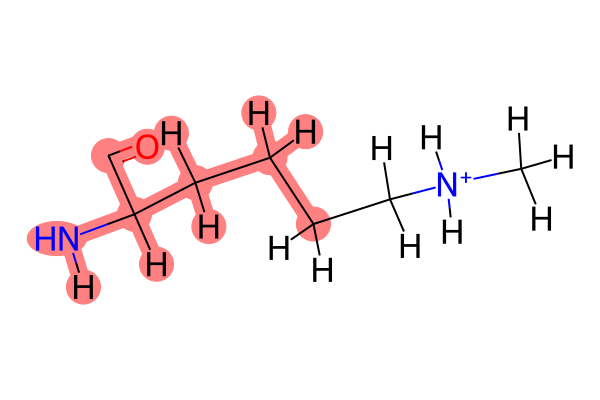

In [32]:
modifie_residue

### Шаг 4.1. Протонирование атомов, потерявших стандартную валентность 

Этот шаг необходим для дальнейшего получения файла itp для нашей а.к. \
Дело в том, что acpype отказывается создавать топологию для атомов с нестандартными валентностями, что вполне логично. Поэтому мы добавляем протоны, которых на самом деле нет в остатке. После в процесе редактирвоания itp мы удалим все строки с лишними протонами. \
Стоит отметить, что этот шаг можно также выполнить с использованием любого удобного вам молекулярного редактора (ChimeraX, PyMOL) взяв за основу pdb фаийл сохраненный на 3-ем шаге.

In [33]:
# Создание карты индексов атомов и их номеров

def add_protons_and_renumber_H(modifie_residue, resname='MOD', resid=1, segid='A'):
    atom_map = {atom.GetIdx(): atom.GetProp('AtomName') for atom in modifie_residue.GetAtoms()}
    names = list(atom_map.values())
    # print(atom_map)

    # Добавление протонов
    H_modifie_residue = Chem.AddHs(modifie_residue, addCoords=True)
    AllChem.Compute2DCoords(H_modifie_residue)
    
    # Назначение уникальных имен для новых атомам водорода
    for atom in H_modifie_residue.GetAtoms():
        if atom.GetPDBResidueInfo() is None:
            info = atom.GetPDBResidueInfo()
            print(info, atom.GetIdx(), atom.GetAtomMapNum())
            
            new_name = 'HW1'
            while new_name in names:
                new_name = increment_name(new_name)
            names.append(new_name)

            set_PDB_residue_info(atom, new_name, resname, resid, segid)
            atom.SetProp('AtomName', new_name)
            atom.SetAtomMapNum(atom.GetIdx())
            # atom.SetI() = int(atom.GetAtomMapNum())
        
    order = [atom.GetIdx() for atom in H_modifie_residue.GetAtoms()]
    Chem.rdmolops.RenumberAtoms(H_modifie_residue, order)
    
    return H_modifie_residue

In [34]:
H_modifie_residue = add_protons_and_renumber_H(modifie_residue, resname = base_name, resid=2, segid='A')

None 25 0
None 26 0


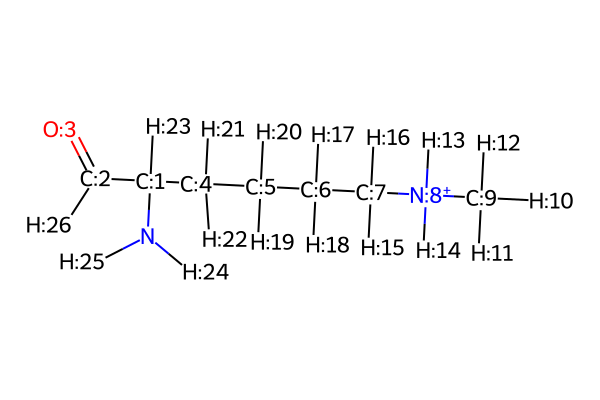

In [35]:
pt.draw_mol_with_atom_index(H_modifie_residue)

In [36]:
for atom in H_modifie_residue.GetAtoms():
    info = atom.GetPDBResidueInfo()
    print(info.GetResidueNumber(), info.GetResidueName(), atom.GetProp('AtomName'), atom.GetIdx(), atom.GetAtomMapNum())

2 K1M N 0 0
2 K1M CA 1 1
2 K1M C 2 2
2 K1M O 3 3
2 K1M CB 4 4
2 K1M CG 5 5
2 K1M CD 6 6
2 K1M CE 7 7
2 K1M NZ 8 8
2 K1M CH 9 9
2 K1M HH3 10 10
2 K1M HH2 11 11
2 K1M HH1 12 12
2 K1M HZ2 13 13
2 K1M HZ1 14 14
2 K1M HE2 15 15
2 K1M HE1 16 16
2 K1M HD2 17 17
2 K1M HD1 18 18
2 K1M HG2 19 19
2 K1M HG1 20 20
2 K1M HB2 21 21
2 K1M HB1 22 22
2 K1M HA 23 23
2 K1M H 24 24
2 K1M HW1 25 25
2 K1M HW2 26 26


In [37]:

save_molecule_as_pdb(H_modifie_residue, f'molecules/substructure/{PTM_name}_rn_H.pdb', format_coord='3D')

Молекула успешно сохранена в файле molecules/substructure/Lysine_1M_rn_H_3D.pdb в формате 3D.


In [38]:
pt.save_aa_chem_to_smiles(H_modifie_residue, f'molecules/substructure/{chem_name}_rn_H.smiles', canonical=False ,make_N_root=False)

Lysine_1M_rn_Hles.smiles saved to molecules/substructure


In [37]:
test = mda.Universe(f'{PTM_name}/molecules/substructure/{PTM_name}_rn_H_3D.pdb')
nv.show_mdanalysis(test)

NGLWidget()

#### Дополнителоьные шаги отладки

In [60]:
chek_mol = mda.Universe('molecules/substructure/Lysin_2M_RENAME.pdb')

all_mod_atom_names = chek_mol.atoms.names
name_counts = Counter(all_mod_atom_names)  # Подсчитываем частоту каждого имени
duplicates = [name for name, count in name_counts.items() if count > 1]  # Список дубликатов

if duplicates:
    print("В модифицированной молекуле обнаружены повторяющиеся имена атомов:")
    for name in duplicates:
        print(f"Имя: {name}, количество повторений: {name_counts[name]}")
    raise ValueError("Обнаружены повторяющиеся имена атомов. Проверьте логи для деталей.")
else:
    print("Все имена атомов уникальны.")

Все имена атомов уникальны.


/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:432: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


In [97]:
nv.show_mdanalysis(mda.Universe('molecules/substructure/Lysin_1M_RENAME.pdb'))

NGLWidget()

In [99]:
pt.draw_mol_with_atom_index(mod_aa_chem_dict['Lysin_3M'])

KeyError: 'Lysin_3M'

In [48]:
mod_aa_chem_dict['Lysin_3M'].GetNumAtoms()

33

In [207]:
test_pdb_dict = pt.pdb_to_chem('molecules/substructure/TestNR_CIT_mod.pdb')
ref_aa = pt.pdb_to_chem('molecules/aminoacids_template/RRR.pdb')
print(test_pdb_dict, ref_aa)

{'RRR': <rdkit.Chem.rdchem.Mol at 0x7fbfb9a03640>}

In [196]:
substructure, dict_mol1_mol2_matches = pt.match_chem(ref_aa['RRR'], test_pdb_dict['TestNR_CIT_mod'])

In [205]:
substructure.GetNumAtoms()

23

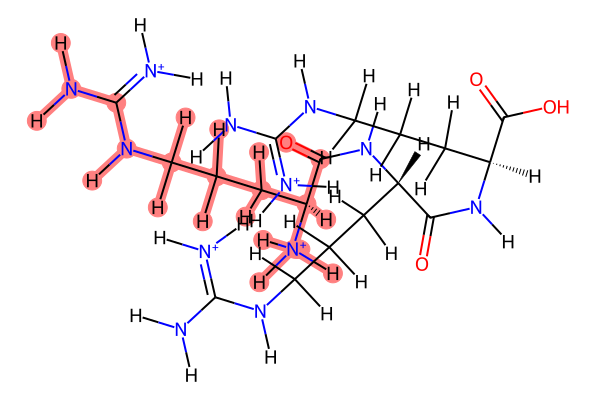

In [197]:
ref_aa['RRR']

In [25]:
# NR = mda.Universe('molecules/aminoacids_template/NR.pdb')
NRCIT = mda.Universe('molecules/substructure/TestNR_CIT_mod.pdb')
NRCIT.residues.resnums

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(


array([2])

In [184]:
for ref_indx, mod_indx in dict_mol1_mol2_matches.items():
    print( NR.atoms.names[ref_indx] + ':' + NRCIT.atoms.names[mod_indx])

N:N1
CA:C1
CB:C2
CG:C3
CD:C4
NE:N2
CZ:C5
NH1:N3
HH11:H1
HH12:H2
HE:H3
HD2:H4
HD3:H5
HG2:H6
HG3:H7
HB2:H8
HB3:H9
C:C6
O:O2
HA:H10
H1:H11
H2:H12
H3:H13


/home/n_kristovsky/.conda/envs/topmol2/lib//python3.8/site-packages/MDAnalysis/coordinates/PDB.py:432: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


In [193]:
for ref_indx, mod_indx in dict_mol1_mol2_matches.items():
    NRCIT.atoms[mod_indx].name = NR.atoms[ref_indx].name 
print(NRCIT.atoms.names)

['N' 'CA' 'CB' 'CG' 'CD' 'NE' 'CZ' 'NH1' 'HH11' 'HH12' 'O1' 'HE' 'HD2'
 'HD3' 'HG2' 'HG3' 'HB2' 'HB3' 'C' 'O' 'HA' 'H1' 'H2' 'H3']


In [190]:
# NRCIT.atoms.names[1] = 'AD'
NRCIT.atoms.

'C1'

In [191]:
print(dict_mon_pol_matches)

{0: 0, 1: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 19: 8, 20: 9, 18: 11, 16: 12, 17: 13, 14: 14, 15: 15, 12: 16, 13: 17, 2: 18, 3: 19, 11: 20, 23: 21, 24: 22, 25: 23}


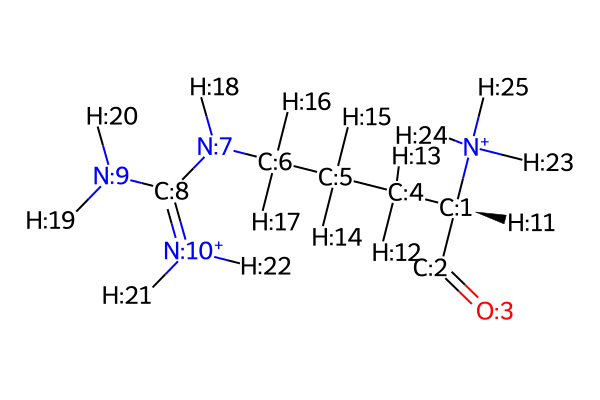

In [177]:
pt.draw_mol_with_atom_index(ref_aa['NR'])

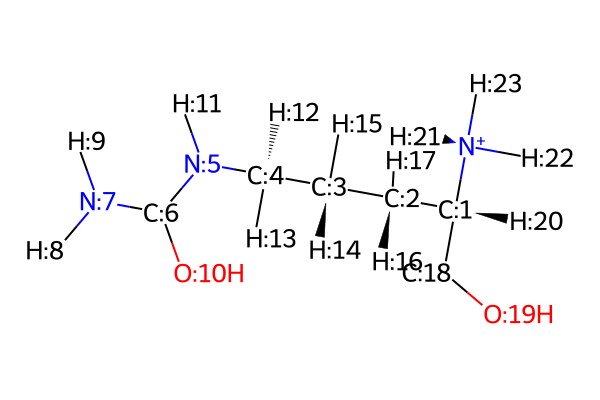

In [169]:
pt.draw_mol_with_atom_index(test_pdb_dict['TestNR_CIT_mod'])

In [151]:
mda_sub.residues.resids

array([1])

In [ ]:
list_N = []
for sub in match_dict['substructure'].values():
    N_index = pt.find_amino_nitrogen(sub)
    list_N.append(N_index)
print(list_N)
sub_name = ['NR_CIT', 'R_CIT', 'CR_CIT']
for chem_name, chem_mol, root in zip(sub_name, match_dict['substructure'].values(), list_N):
    pt.save_chem_to_pdb(chem_mol, f'molecules/substructure/{chem_name}', rootedAtAtom = root)
    print(chem_name, chem_mol)

## Шаг 5. Расчет зарядов при помощи библиотеки Espaloma Charge

На вход: 
- Молекула-ы в виде тримеров в формате smiles. 

Задача ограничейни зарядов для одной молекулы


Создание ограничений

In [6]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks/Lysine_1M


In [7]:
PTM_name

'Lysine_1M'

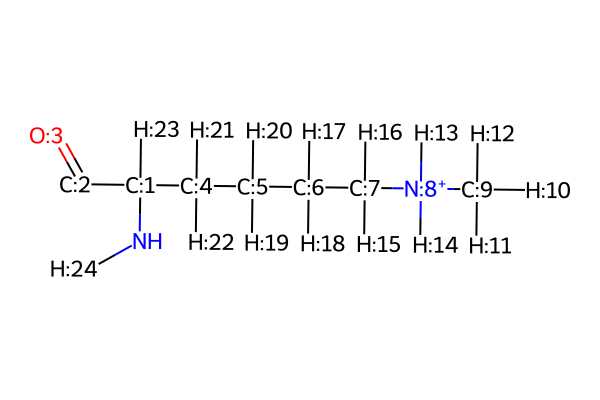

In [8]:
residue = pt.pdb_to_chem(f'molecules/substructure/{mon_name}.pdb')
pt.draw_mol_with_atom_index(residue[mon_name])

In [9]:
constraint_dict = {f'{mon_name}':
                  {'symmetric_list': [],
                   'charge_atom_dict': {0:-0.34790, 24:0.27470, 
                                        1:-0.24000, 2:0.73410, 
                                        3:-0.58940, 23:0.14260},
                   'charge_of_monomer': 1.0000,
                  }
                  }

### Расчет зарядов при помощи библиотеки Espaloma Charge

In [10]:
charges = charge(residue[mon_name], 
                 constraints=constraint_dict[mon_name]['charge_atom_dict']
                )

print(f'Суммарный заряд молекулы: {sum(charges)}', charges, sep = '\n')


/home/n_kristovsky/.conda/envs/espaloma/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


Суммарный заряд молекулы: 1.0
[-0.3479     -0.24        0.7341     -0.5894     -0.1970251  -0.22330597
 -0.19959679 -0.02957197 -0.6957726  -0.07841596  0.19370374  0.19370374
  0.19370374  0.29249054  0.29249054  0.19166155  0.19166155  0.16812657
  0.16812657  0.14138722  0.14138716  0.1405727   0.1405727   0.1426
  0.2747    ]


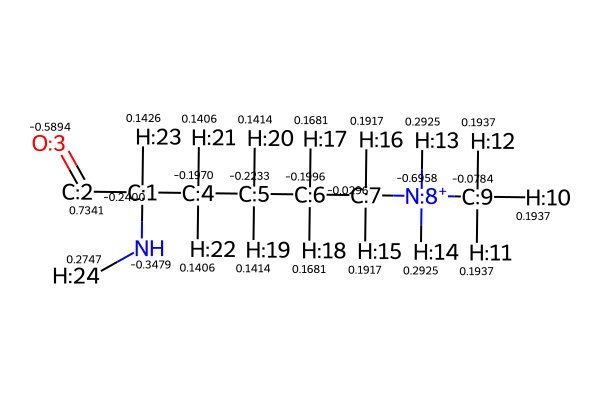

In [11]:
pt.draw_mol_with_atom_index(residue[mon_name], charge_list=charges)

## Сохранение масcива зарядов

In [12]:
pt.save_charges_json(name = f'AI_chrges_{mon_name}', charge_list = charges.tolist(),  )

Файл успешно сохранен: 
/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks/Lysine_1M/AI_chrges_Lysine_1M.json
